In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from baseline_logreg.preprocessing import build_preprocessor

In [2]:
df = pd.read_csv("../../simplified-CBIS-DDSM/features.csv")

TARGET_MAPPING = {
    "BENIGN": 0,
    "MALIGNANT": 1
}
X = df.drop(columns=["pathology"])
y = df["pathology"].map(TARGET_MAPPING)

preprocessor = build_preprocessor(X)

In [3]:
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}

In [4]:
results = []
all_cv_results = {}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Models              mean   Standard Deviation")
for model_name, model in models.items():

    try:
        pipeline = Pipeline(steps=[
            ("preprocessing", preprocessor),
            ("classifier", model)
        ])

        cv_results = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )
        all_cv_results[model_name] = cv_results
        
        for metric in scoring.keys():
            mean_val = np.mean(cv_results[f"test_{metric}"])
            std_val = np.std(cv_results[f"test_{metric}"])
            
            results.append({
                "Model": model_name,
                "Metric": metric,
                "Mean": mean_val,
                "Std": std_val
            })
        print(f"{model_name}")
        print(f"  Precision:        {np.mean(cv_results['test_precision']):.3f}  {np.std(cv_results['test_precision']):.3f}")
        print(f"  Recall:           {np.mean(cv_results['test_recall']):.3f}  {np.std(cv_results['test_recall']):.3f}")
        print(f"  F1:               {np.mean(cv_results['test_f1']):.3f}  {np.std(cv_results['test_f1']):.3f}")
        print(f"  ROC-AUC:          {np.mean(cv_results['test_roc_auc']):.3f}  {np.std(cv_results['test_roc_auc']):.3f}")
        
    except Exception as e:
        print(f"✗ {model_name}: BŁĄD - {str(e)}")
        for metric in scoring.keys():
            results.append({
                "Model": model_name,
                "Metric": metric,
                "Mean": np.nan,
                "Std": np.nan
            })

Models              mean   Standard Deviation
Logistic Regression
  Precision:        0.827  0.024
  Recall:           0.830  0.024
  F1:               0.828  0.012
  ROC-AUC:          0.910  0.010
SVM (RBF)
  Precision:        0.737  0.039
  Recall:           0.718  0.027
  F1:               0.727  0.021
  ROC-AUC:          0.840  0.017
Random Forest
  Precision:        0.763  0.045
  Recall:           0.621  0.024
  F1:               0.685  0.031
  ROC-AUC:          0.809  0.022
kNN
  Precision:        0.639  0.033
  Recall:           0.632  0.018
  F1:               0.635  0.023
  ROC-AUC:          0.703  0.025


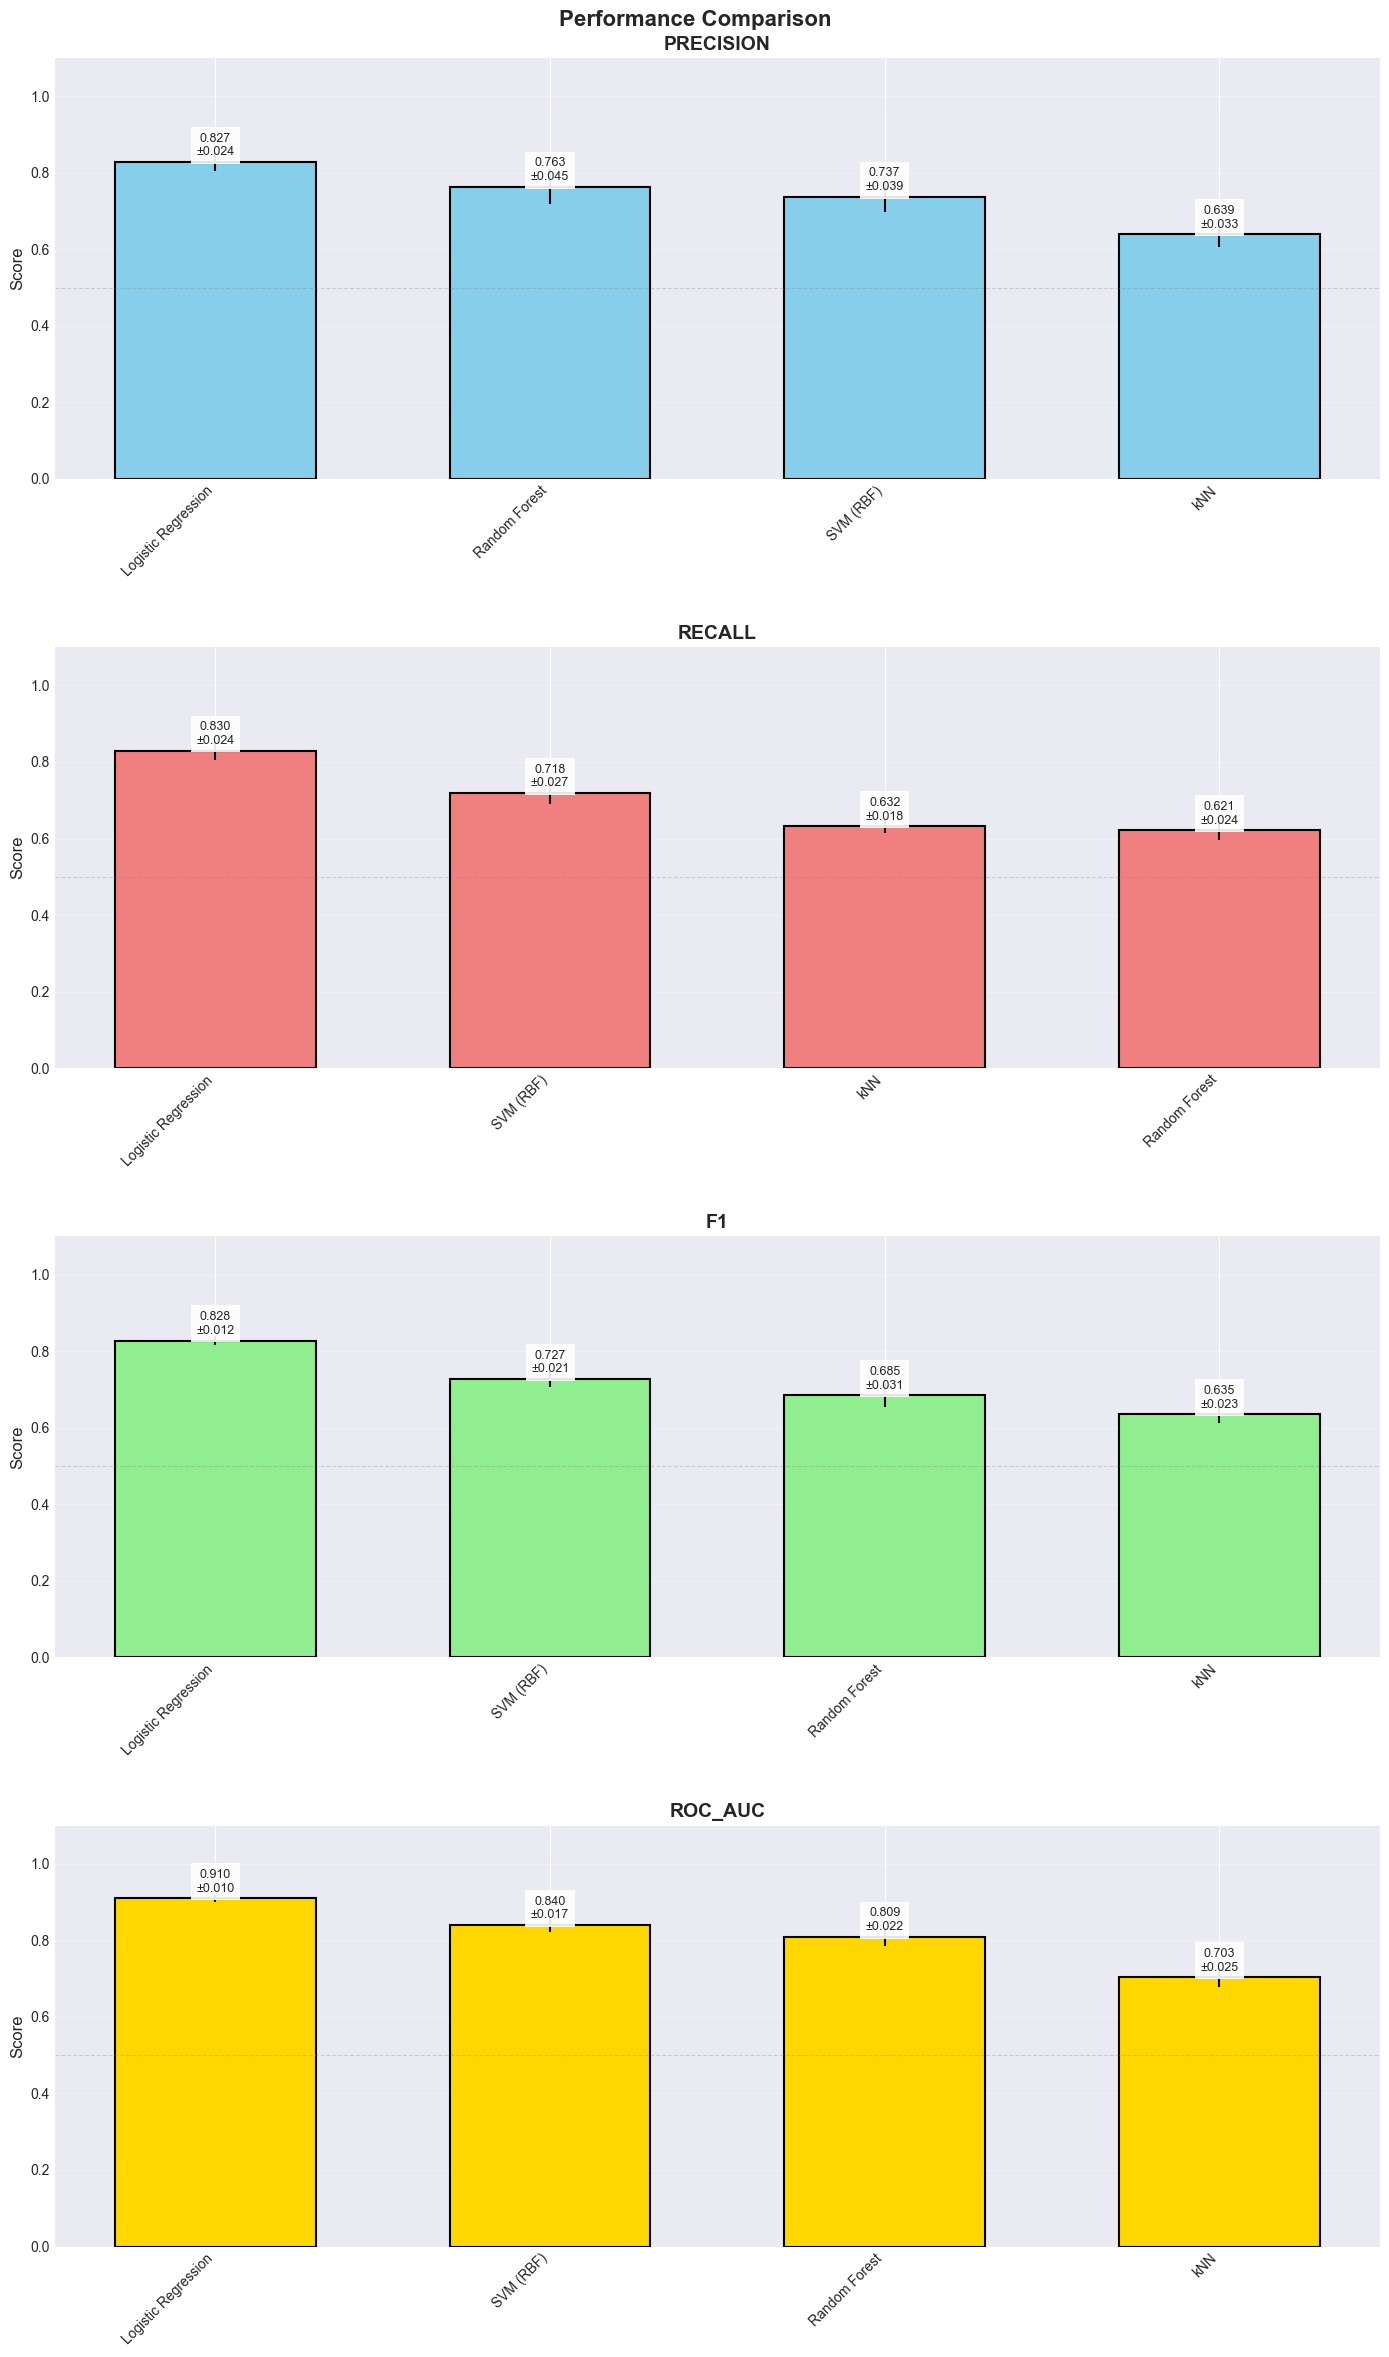

In [5]:
results_df = pd.DataFrame(results)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

metrics_list = list(scoring.keys())
fig, axes = plt.subplots(len(metrics_list), 1, figsize=(14, 6 * len(metrics_list)))
fig.suptitle('Performance Comparison', fontsize=16, fontweight='bold')

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

if len(metrics_list) == 1:
    axes = [axes]

for idx, (metric, ax) in enumerate(zip(metrics_list, axes)):
    metric_data = results_df[results_df["Metric"] == metric].sort_values("Mean", ascending=False)
    
    x_pos = np.arange(len(metric_data["Model"]))
    bars = ax.bar(x_pos, metric_data["Mean"], 
                  color=colors[idx % len(colors)],
                  edgecolor='black',
                  linewidth=1.5,
                  width=0.6)
    
    ax.errorbar(x_pos, metric_data["Mean"], 
                yerr=metric_data["Std"], 
                fmt='none', 
                color='black', 
                capsize=5,
                capthick=0)
    
    for bar, mean_val, std_val in zip(bars, metric_data["Mean"], metric_data["Std"]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{mean_val:.3f}\n±{std_val:.3f}',
                ha='center', va='bottom', fontsize=9,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.9)
        )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metric_data["Model"], rotation=45, ha='right', fontsize=10)
    
    ax.set_title(f'{metric.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.1)
    
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)


plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.4)
plt.show()